In [3]:
import pandas as pd
import re

def parse_can_log(file_path):
    """Parse CAN log file and return a pandas DataFrame"""
    data = []
    
    with open(file_path, 'r') as f:
        for line in f:
            # Extract fields using regex
            match = re.search(r'Timestamp:\s([\d.]+)\s+ID:\s(\w+)\s+(\w+)\s+DLC:\s(\d+)\s+(.*)', line)
            if match:
                timestamp, can_id, flags, dlc, hex_data = match.groups()
                data.append({
                    'Timestamp': float(timestamp),
                    'ID': can_id,
                    'Flags': flags,
                    'DLC': int(dlc),
                    'Data': hex_data.strip()
                })
    
    df = pd.DataFrame(data)
    return df

# Usage
df = parse_can_log('dataset\\normal_run_data\\normal_run_data.txt')
df["Attack"] = "R"
print(df)

           Timestamp    ID Flags  DLC                     Data Attack
0       1.479121e+09  0350   000    8  05 28 84 66 6d 00 00 a2      R
1       1.479121e+09  02c0   000    8  14 00 00 00 00 00 00 00      R
2       1.479121e+09  0430   000    8  00 00 00 00 00 00 00 00      R
3       1.479121e+09  04b1   000    8  00 00 00 00 00 00 00 00      R
4       1.479121e+09  01f1   000    8  00 00 00 00 00 00 00 00      R
...              ...   ...   ...  ...                      ...    ...
988866  1.479122e+09  02b0   000    5           ac 05 0c 07 7f      R
988867  1.479122e+09  0316   000    8  05 38 10 0c 38 28 01 7a      R
988868  1.479122e+09  018f   000    8  fe 31 00 00 00 4b 00 00      R
988869  1.479122e+09  0260   000    8  32 38 39 30 ff 93 59 1c      R
988870  1.479122e+09  02a0   000    8  20 00 75 1d 01 04 dd 00      R

[988871 rows x 6 columns]


In [4]:
def parse_can_csv(file_path):
    df_can = pd.read_csv(file_path, skipinitialspace=True)

    if 'ID dlc' in df_can.columns:
        df_can[['ID', 'DLC']] = df_can['ID dlc'].astype(str).str.split(r'\s+', n=1, expand=True)
        df_can = df_can.drop(columns=['ID dlc'])
    elif set(['Timestamp','ID','DLC','data1','data2','data3','data4','data5','data6','data7','data8','attack/nonattack']).issubset(df_can.columns):
        df_can = df_can.rename(columns={'attack/nonattack': 'Attack'})
    else:
        names = ['Timestamp','ID','DLC','data1','data2','data3','data4','data5','data6','data7','data8','Attack']
        df_can = pd.read_csv(file_path, header=None, names=names, skipinitialspace=True)

    unnamed = [c for c in df_can.columns if isinstance(c, str) and c.startswith('Unnamed')]
    if 'Attack' not in df_can.columns and unnamed:
        df_can = df_can.rename(columns={unnamed[-1]: 'Attack'})

    data_cols = sorted(
        [c for c in df_can.columns if isinstance(c, str) and c.lower().startswith('data')],
        key=lambda x: int(re.search(r'\d+', x).group()) if re.search(r'\d+', x) else 0
    )

    def build_data(row):
        try:
            dlc = int(row['DLC'])
        except Exception:
            dlc = 0

        values = []
        for col in data_cols[:min(dlc, len(data_cols))]:
            val = row.get(col)
            if pd.isna(val):
                continue
            s = str(val).strip()
            if s.lower() in ['', 'nan']:
                continue
            values.append(s)

        return ' '.join(values).strip()

    def infer_attack(row):
        attack = row.get('Attack')
        if isinstance(attack, str) and attack.strip():
            return attack

        try:
            dlc = int(row['DLC'])
        except Exception:
            dlc = 0

        for col in data_cols[min(dlc, len(data_cols)):]:
            val = row.get(col)
            if pd.isna(val):
                continue
            s = str(val).strip()
            if s.lower() in ['', 'nan']:
                continue
            if not re.fullmatch(r'[0-9A-Fa-f]{2}', s):
                return s

        return pd.NA

    if data_cols:
        df_can['Data'] = df_can.apply(build_data, axis=1)
        if 'Attack' not in df_can.columns:
            df_can['Attack'] = pd.NA
        df_can['Attack'] = df_can.apply(infer_attack, axis=1).combine_first(df_can['Attack'])
    else:
        df_can['Data'] = df_can.get('Data', '').astype(str).str.strip()
        if 'Attack' not in df_can.columns:
            df_can['Attack'] = pd.NA

    df_can['Timestamp'] = pd.to_numeric(df_can['Timestamp'], errors='coerce')
    df_can['DLC'] = pd.to_numeric(df_can['DLC'], errors='coerce').astype('Int64')

    return df_can[['Timestamp','ID','DLC','Data','Attack']]

In [5]:
import numpy as np

def sliding_windows_id_data(df, window_size=8, step=2, attack_label='T'):
    ids = df['ID'].to_numpy(dtype=object)
    data = df['Data'].to_numpy(dtype=object)
    attack = df['Attack'].to_numpy(dtype=object)

    n = len(df)
    num_windows = (n - window_size) // step + 1
    windows = []
    window_labels = []

    for start in range(0, n - window_size + 1, step):
        end = start + window_size
        windows.append(np.column_stack((ids[start:end], data[start:end])))
        window_labels.append(attack_label if 'T' in attack[start:end] else 'R')

    return windows, np.array(window_labels, dtype=object)


In [6]:
windowed_id_data, window_attack_labels = sliding_windows_id_data(df, attack_label='T')

del df

In [7]:
df_DoS = parse_can_csv(r'dataset\DoS_dataset.csv')
print(df_DoS.head())
windowed_id_data1, window_attack_labels1 = sliding_windows_id_data(df_DoS[:555389], attack_label='D')

del df_DoS

      Timestamp    ID  DLC                     Data Attack
0  1.478198e+09  0316    8  05 21 68 09 21 21 00 6f      R
1  1.478198e+09  018f    8  fe 5b 00 00 00 3c 00 00      R
2  1.478198e+09  0260    8  19 21 22 30 08 8e 6d 3a      R
3  1.478198e+09  02a0    8  64 00 9a 1d 97 02 bd 00      R
4  1.478198e+09  0329    8  40 bb 7f 14 11 20 00 14      R


In [8]:
df_Fuzzy = parse_can_csv(r'dataset\Fuzzy_dataset.csv')
print(df_Fuzzy.head())
windowed_id_data2, window_attack_labels2 = sliding_windows_id_data(df_Fuzzy[:555389], attack_label='F')

del df_Fuzzy

      Timestamp    ID  DLC                     Data Attack
0  1.478196e+09  0545    8  d8 00 00 8a 00 00 00 00      R
1  1.478196e+09  02b0    5           ff 7f 00 05 49      R
2  1.478196e+09  0002    8  00 00 00 00 00 01 07 15      R
3  1.478196e+09  0153    8  00 21 10 ff 00 ff 00 00      R
4  1.478196e+09  0130    8  19 80 00 ff fe 7f 07 60      R


In [9]:
df_gear = parse_can_csv(r'dataset\gear_dataset.csv')
print(df_gear.head())
windowed_id_data3, window_attack_labels3 = sliding_windows_id_data(df_gear[:555389], attack_label='S')

del df_gear

      Timestamp    ID  DLC                     Data Attack
0  1.478193e+09  0140    8  00 00 00 00 10 29 2a 24      R
1  1.478193e+09  02c0    8  15 00 00 00 00 00 00 00      R
2  1.478193e+09  0350    8  05 20 44 68 77 00 00 7e      R
3  1.478193e+09  0370    8  00 20 00 00 00 00 00 00      R
4  1.478193e+09  043f    8  10 40 60 ff 78 c4 08 00      R


In [10]:
df_RPM = parse_can_csv(r'dataset\RPM_dataset.csv')
print(df_RPM.head())
windowed_id_data4, window_attack_labels4 = sliding_windows_id_data(df_RPM[:555389], attack_label='S')

del df_RPM

      Timestamp    ID  DLC                     Data Attack
0  1.478191e+09  0316    8  05 22 68 09 22 20 00 75      R
1  1.478191e+09  018f    8  fe 3b 00 00 00 3c 00 00      R
2  1.478191e+09  0260    8  19 22 22 30 ff 8f 6e 3f      R
3  1.478191e+09  02a0    8  60 00 83 1d 96 02 bd 00      R
4  1.478191e+09  0329    8  dc b8 7e 14 11 20 00 14      R


In [11]:
print(len(windowed_id_data), windowed_id_data[:10])

494432 [array([['0350', '05 28 84 66 6d 00 00 a2'],
       ['02c0', '14 00 00 00 00 00 00 00'],
       ['0430', '00 00 00 00 00 00 00 00'],
       ['04b1', '00 00 00 00 00 00 00 00'],
       ['01f1', '00 00 00 00 00 00 00 00'],
       ['0153', '00 00 00 ff 00 ff 00 00'],
       ['0002', '00 00 00 00 00 00 00 0a'],
       ['018f', 'fe 36 00 00 00 3c 00 00']], dtype=object), array([['0430', '00 00 00 00 00 00 00 00'],
       ['04b1', '00 00 00 00 00 00 00 00'],
       ['01f1', '00 00 00 00 00 00 00 00'],
       ['0153', '00 00 00 ff 00 ff 00 00'],
       ['0002', '00 00 00 00 00 00 00 0a'],
       ['018f', 'fe 36 00 00 00 3c 00 00'],
       ['0130', '03 80 00 ff 21 80 00 9d'],
       ['0131', '00 80 00 00 2d 7f 00 97']], dtype=object), array([['01f1', '00 00 00 00 00 00 00 00'],
       ['0153', '00 00 00 ff 00 ff 00 00'],
       ['0002', '00 00 00 00 00 00 00 0a'],
       ['018f', 'fe 36 00 00 00 3c 00 00'],
       ['0130', '03 80 00 ff 21 80 00 9d'],
       ['0131', '00 80 00 00 2d 7f 0

In [12]:
def _hex_byte_list_from_row(row):
    msg_id, data = row
    msg_id = str(msg_id).strip()
    if len(msg_id) % 2 != 0:
        msg_id = '0' + msg_id
    id_bytes = [msg_id[i:i+2] for i in range(0, len(msg_id), 2)]
    data_bytes = [b for b in str(data).split() if b]
    return [int(b, 16) for b in id_bytes + data_bytes]

def convert_windowed_id_data_to_ints(windowed_data, pad_value=0):
    int_windows = []
    for window in windowed_data:
        rows = [_hex_byte_list_from_row(row) for row in window]
        max_len = max(len(r) for r in rows)
        padded_rows = [r + [pad_value] * (max_len - len(r)) for r in rows]
        int_windows.append(np.array(padded_rows, dtype=np.uint8))
    return int_windows

int_windowed_id_data = convert_windowed_id_data_to_ints(windowed_id_data)

print(int_windowed_id_data[0].shape)
print(int_windowed_id_data[0][:2])

(8, 10)
[[  3  80   5  40 132 102 109   0   0 162]
 [  2 192  20   0   0   0   0   0   0   0]]


In [13]:
int_windowed_id_data

[array([[  3,  80,   5,  40, 132, 102, 109,   0,   0, 162],
        [  2, 192,  20,   0,   0,   0,   0,   0,   0,   0],
        [  4,  48,   0,   0,   0,   0,   0,   0,   0,   0],
        [  4, 177,   0,   0,   0,   0,   0,   0,   0,   0],
        [  1, 241,   0,   0,   0,   0,   0,   0,   0,   0],
        [  1,  83,   0,   0,   0, 255,   0, 255,   0,   0],
        [  0,   2,   0,   0,   0,   0,   0,   0,   0,  10],
        [  1, 143, 254,  54,   0,   0,   0,  60,   0,   0]], dtype=uint8),
 array([[  4,  48,   0,   0,   0,   0,   0,   0,   0,   0],
        [  4, 177,   0,   0,   0,   0,   0,   0,   0,   0],
        [  1, 241,   0,   0,   0,   0,   0,   0,   0,   0],
        [  1,  83,   0,   0,   0, 255,   0, 255,   0,   0],
        [  0,   2,   0,   0,   0,   0,   0,   0,   0,  10],
        [  1, 143, 254,  54,   0,   0,   0,  60,   0,   0],
        [  1,  48,   3, 128,   0, 255,  33, 128,   0, 157],
        [  1,  49,   0, 128,   0,   0,  45, 127,   0, 151]], dtype=uint8),
 array([[ 

In [14]:
flattened_int_windowed_id_data = [window.ravel() for window in int_windowed_id_data]

# verify each window flattened to 80 bytes
assert all(arr.size == 80 for arr in flattened_int_windowed_id_data)

print(flattened_int_windowed_id_data[0].shape)
print(flattened_int_windowed_id_data[0])

(80,)
[  3  80   5  40 132 102 109   0   0 162   2 192  20   0   0   0   0   0
   0   0   4  48   0   0   0   0   0   0   0   0   4 177   0   0   0   0
   0   0   0   0   1 241   0   0   0   0   0   0   0   0   1  83   0   0
   0 255   0 255   0   0   0   2   0   0   0   0   0   0   0  10   1 143
 254  54   0   0   0  60   0   0]


In [15]:
window_attack_onehot = np.zeros((len(window_attack_labels), 4), dtype=np.uint8)
window_attack_onehot[window_attack_labels == 'R', 0] = 1
window_attack_onehot[window_attack_labels == 'D', 1] = 1
window_attack_onehot[window_attack_labels == 'F', 2] = 1
window_attack_onehot[window_attack_labels == 'S', 3] = 1

print(window_attack_onehot[:10])

[[1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]
 [1 0 0 0]]


In [16]:
len(flattened_int_windowed_id_data)

494432

In [17]:
len(window_attack_onehot)

494432

In [18]:
import numpy as np
from sklearn.model_selection import train_test_split

# prepare arrays
X = np.stack(flattened_int_windowed_id_data)  # shape (N, 80)
y = window_attack_onehot

# attempt stratified split, fallback if stratify not possible
try:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y, shuffle=True)
except ValueError:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

print("X_train:", X_train.shape, "X_test:", X_test.shape, "y_train:", y_train.shape, "y_test:", y_test.shape)

X_train: (395545, 80) X_test: (98887, 80) y_train: (395545, 4) y_test: (98887, 4)


In [19]:
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
from tensorflow.keras.models import Model

class Autoencoder(Model):
  def __init__(self, latent_dim, shape):
    super(Autoencoder, self).__init__()
    self.latent_dim = latent_dim
    self.shape = shape
    self.encoder = tf.keras.Sequential([
      layers.Flatten(),
      layers.Dense(120, activation='relu'),
      layers.Dense(latent_dim, activation='relu'),
    ])
    self.decoder = tf.keras.Sequential([
      layers.Dense(120, activation='relu'),
      layers.Dense(tf.math.reduce_prod(shape).numpy(), activation='relu'),
      layers.Reshape(shape)
    ])

  def call(self, x):
    encoded = self.encoder(x)
    decoded = self.decoder(encoded)
    return decoded


shape = (80,)
latent_dim = 160
autoencoder = Autoencoder(latent_dim, shape)

In [20]:
autoencoder.compile(optimizer='adam', metrics=['accuracy'], loss=losses.MeanSquaredError())

autoencoder.fit(X_train, X_train,
                epochs=10,
                validation_data=(X_test, X_test))

Epoch 1/10
12361/12361 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - accuracy: 0.2718 - loss: 496.5620 - val_accuracy: 0.1969 - val_loss: 434.9594
Epoch 2/10
12361/12361 ━━━━━━━━━━━━━━━━━━━━ 18s 1ms/step - accuracy: 0.2782 - loss: 435.3815 - val_accuracy: 0.3324 - val_loss: 435.3511
Epoch 3/10
12361/12361 ━━━━━━━━━━━━━━━━━━━━ 18s 1ms/step - accuracy: 0.2804 - loss: 434.7175 - val_accuracy: 0.2042 - val_loss: 434.8566
Epoch 4/10
12361/12361 ━━━━━━━━━━━━━━━━━━━━ 18s 1ms/step - accuracy: 0.2807 - loss: 434.3018 - val_accuracy: 0.2894 - val_loss: 435.1294
Epoch 5/10
12361/12361 ━━━━━━━━━━━━━━━━━━━━ 18s 1ms/step - accuracy: 0.2805 - loss: 434.0122 - val_accuracy: 0.2552 - val_loss: 431.6634
Epoch 6/10
12361/12361 ━━━━━━━━━━━━━━━━━━━━ 19s 1ms/step - accuracy: 0.2817 - loss: 433.7692 - val_accuracy: 0.3168 - val_loss: 436.8799
Epoch 7/10
12361/12361 ━━━━━━━━━━━━━━━━━━━━ 18s 1ms/step - accuracy: 0.2817 - loss: 433.6430 - val_accuracy: 0.3990 - val_loss: 434.6352
Epoch 8/10
12361/12361 ━━━━━━━━━━━━━━━━━━

In [21]:
encoded_data = autoencoder.encoder(X_test).numpy()
decoded_data = autoencoder.decoder(encoded_data).numpy()
decoded_int = np.rint(decoded_data).astype(np.int32)

In [22]:
print(X_test[0])
print(decoded_int[0])

[  2 176 105 255   0   7 230   0   0   0   1  48 214 127   0 255 238 126
   9 184   1  49 142 127   0   0 204 128   9 149   1  64   0   0   0   0
  10   0  41 119   3 112   0  35   0   0   0   0   0   0   4  63   3  69
  96 255  92  96  20   0   4  64 255   3  25   0 255  96  20  98   2 192
  20   0   0   0   0   0   0   0]
[  0 176 105   0   0   0 233   0   0   0   0  50 213 131   0 257 240 126
  12 182   0  47 138 124   0   0 202 123  10 151   0  64   0   0   0   0
   8   0  41 120   0 107   0  35   0   4   0   3   0   1   0  61   2  67
  98 254  93  94  20   0   0  66 256   1  21   0 252  93  17  95   0 190
  20   0   0   0   1   0   0   4]


In [23]:
encoded_data[0]

array([103.06356 ,   0.      ,   0.      ,  80.17616 , 133.8515  ,
       117.671936, 167.56949 , 157.74823 ,   0.      ,   0.      ,
        60.481857,  57.26982 ,  77.13571 , 225.24629 ,  30.261183,
       135.6478  , 150.25293 , 178.61137 , 113.75878 ,  65.375496,
        96.07891 ,  16.676243,  95.365524, 130.64194 ,  69.5845  ,
       124.28616 ,   0.      ,  66.34989 , 100.13991 , 199.59785 ,
        84.530655,  82.31992 ,  79.37319 , 111.420654,  52.22764 ,
         0.      ,   0.      ,   0.      ,  91.156685, 101.25357 ,
        88.28646 ,  60.622402,  99.20762 , 158.18456 ,   0.      ,
        38.513283, 180.34889 ,  54.27746 ,  86.658394, 118.8604  ,
       272.0279  , 129.39412 ,  79.657104, 104.16294 , 133.5077  ,
        69.09029 ,   0.      ,   0.      ,  92.393814,  53.44548 ,
         0.      ,  28.442753, 120.95291 , 137.96416 ,  86.08107 ,
       110.97664 , 109.49641 ,  74.508224, 106.55392 ,  46.91377 ,
         0.      , 127.9507  ,  61.909096,   0.      , 111.505

In [24]:
int_windowed_id_data1 = convert_windowed_id_data_to_ints(windowed_id_data1)

print(int_windowed_id_data1[0].shape)
print(int_windowed_id_data1[0][:2])

flattened_int_windowed_id_data1 = [window.ravel() for window in int_windowed_id_data1]

# verify each window flattened to 80 bytes
assert all(arr.size == 80 for arr in flattened_int_windowed_id_data1)

print(flattened_int_windowed_id_data1[0].shape)
print(flattened_int_windowed_id_data1[0])

(8, 10)
[[  3  22   5  33 104   9  33  33   0 111]
 [  1 143 254  91   0   0   0  60   0   0]]
(80,)
[  3  22   5  33 104   9  33  33   0 111   1 143 254  91   0   0   0  60
   0   0   2  96  25  33  34  48   8 142 109  58   2 160 100   0 154  29
 151   2 189   0   3  41  64 187 127  20  17  32   0  20   5  69 216   0
   0 138   0   0   0   0   0   2   0   0   0   0   0   3  11  17   1  83
   0  33  16 255   0 255   0   0]


In [38]:
encoded_data = autoencoder.encoder(np.array(flattened_int_windowed_id_data1[2000:2100], dtype=np.float32)).numpy()
decoded_data = autoencoder.decoder(encoded_data).numpy()
decoded_int = np.rint(decoded_data).astype(np.int32)

In [39]:
def unflatten_windows(flat_windows, shape=(8, 10)):
    flat_arr = np.asarray(flat_windows)
    expected_len = np.prod(shape)

    if flat_arr.ndim == 1:
        if flat_arr.size != expected_len:
            raise ValueError(f"Flat array length must be {expected_len}")
        return flat_arr.reshape(shape)

    if flat_arr.ndim == 2:
        if flat_arr.shape[1] != expected_len:
            raise ValueError(f"Each flattened window must have length {expected_len}")
        return flat_arr.reshape(-1, *shape)

    raise ValueError("Input must be a 1D or 2D array of flattened windows")

unflatten_decoded_int = unflatten_windows(decoded_int, shape=(8, 10))


In [40]:
unflatten_decoded_int

array([[[  0,   3,   3, ...,  10,  15,   6],
        [  0,  79,  24, ..., 112,  72,  17],
        [  0,  16,  19, ...,   5,   0,   5],
        ...,
        [  0,  15,  18, ...,  39,   0,  83],
        [  0,  10,   3, ...,   6,   2,   0],
        [  0,  19,  23, ...,   8,   5,   0]],

       [[  0,   0,  27, ...,  19,  13,   8],
        [  0, 113,   6, ...,  17, 142,  17],
        [  0,  19,  13, ...,  10,  21,   9],
        ...,
        [  0,  23,  18, ...,   4,   7,  13],
        [  0, 200,   9, ...,  85, 150,   1],
        [  0,  22,  12, ...,  12,  18,  14]],

       [[  0,  13,   1, ...,   1,   0,   8],
        [  0,  37,  19, ...,  41,  20,  92],
        [  0,  29,  27, ...,   0,   0,   4],
        ...,
        [  0,  17,  14, ...,   5,   0,   0],
        [  0, 110,   9, ...,  35,   0,   0],
        [  0,  16,   2, ...,   0,   0,  12]],

       ...,

       [[  0,  61,   0, ..., 189,   8,   0],
        [  0,  16,  11, ...,   2,   0,   0],
        [  0,  56, 238, ..., 191,  21,   6

In [41]:
def convert_int_windows_to_can_format(int_windows):
    """
    Convert array of int windows back to CAN format with ID and Data strings.
    
    Each window is shape (8, 10) where:
    - First 2 columns: message ID bytes
    - Remaining 8 columns: data bytes
    """
    can_windows = []
    
    for window in int_windows:
        rows = []
        for row in window:
            # First 2 bytes are ID
            id_bytes = row[:2]
            id_hex = ''.join(f'{b:02x}' for b in id_bytes).upper()
            
            # Remaining 8 bytes are data
            data_bytes = row[2:]
            data_hex = ' '.join(f'{b:02x}' for b in data_bytes).upper()
            
            rows.append([id_hex, data_hex])
        
        can_windows.append(np.array(rows, dtype=object))
    
    return can_windows

# Usage
can_formatted_windows = convert_int_windows_to_can_format(unflatten_decoded_int)

can_formatted_windows

[array([['0003', '03 00 09 00 12 0A 0F 06'],
        ['004F', '18 1C 21 35 05 70 48 11'],
        ['0010', '13 00 01 12 03 05 00 05'],
        ['007B', '2A 02 75 00 6C 13 92 0D'],
        ['0004', '00 00 00 0E 00 1D 08 1D'],
        ['000F', '12 19 59 11 23 27 00 53'],
        ['000A', '03 05 05 14 15 06 02 00'],
        ['0013', '17 24 00 01 0B 08 05 00']], dtype=object),
 array([['0000', '1B 00 00 00 0D 13 0D 08'],
        ['0071', '06 08 80 17 74 11 8E 11'],
        ['0013', '0D 15 18 00 00 0A 15 09'],
        ['002F', '20 27 4A 00 27 20 0F 44'],
        ['0013', '28 12 07 07 00 02 0F 0F'],
        ['0017', '12 17 00 0D 00 04 07 0D'],
        ['00C8', '09 00 01 5C 0C 55 96 01'],
        ['0016', '0C 00 13 13 00 0C 12 0E']], dtype=object),
 array([['000D', '01 00 0A 00 0D 01 00 08'],
        ['0025', '13 17 5B 1E 2B 29 14 5C'],
        ['001D', '1B 00 00 00 02 00 00 04'],
        ['001C', '1F 12 06 00 00 0C 00 14'],
        ['00AD', '00 01 23 60 00 5B 91 00'],
        ['0011', '0E 04

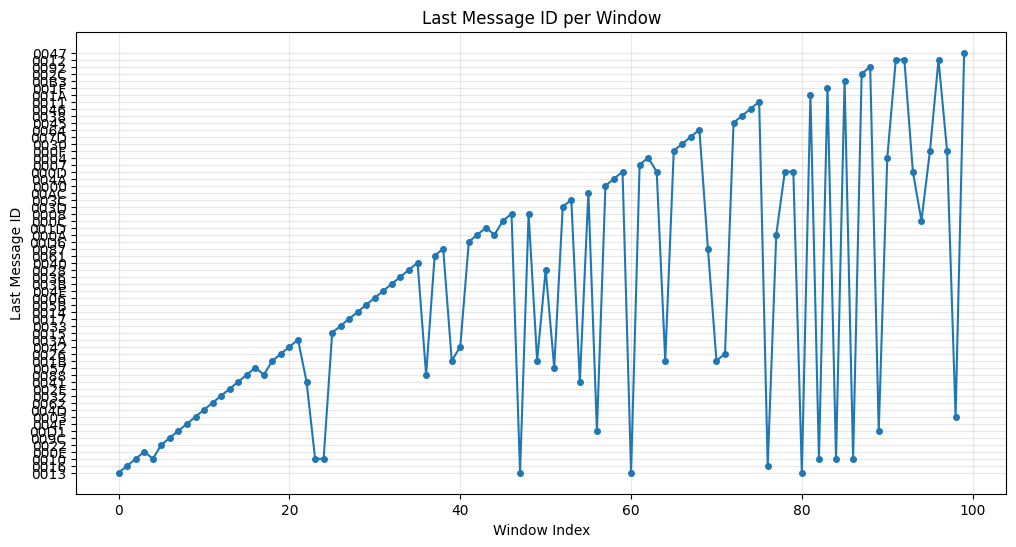

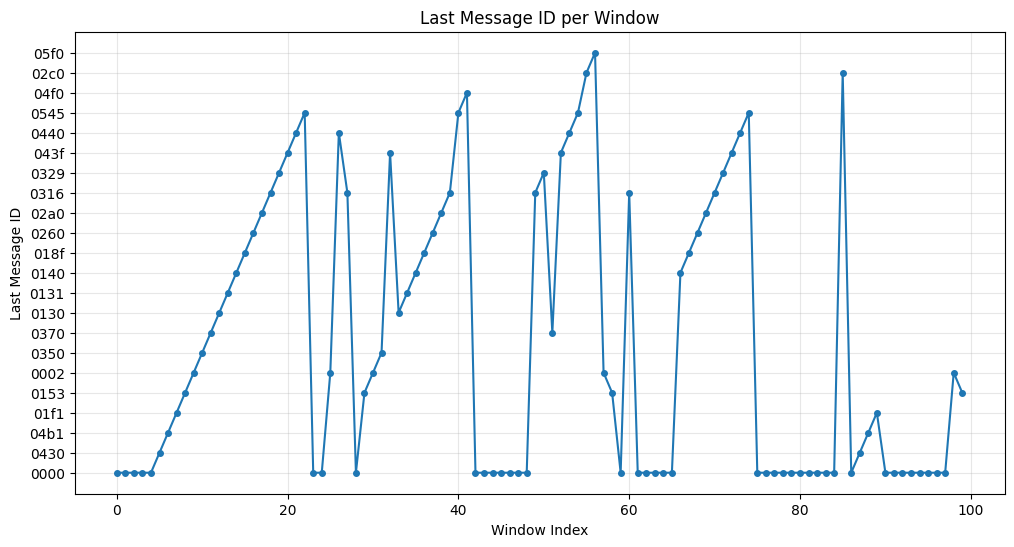

In [42]:
def plot_last_id_per_window(can_windows):
    """Plot the last ID of each window"""
    last_ids = [window[-1, 0] for window in can_windows]
    
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12, 6))
    plt.plot(last_ids, marker='o', linestyle='-', markersize=4)
    plt.xlabel('Window Index')
    plt.ylabel('Last Message ID')
    plt.title('Last Message ID per Window')
    plt.grid(True, alpha=0.3)
    plt.show()

plot_last_id_per_window(can_formatted_windows)
plot_last_id_per_window(windowed_id_data1[2000:2100])